In [1]:
#pip install scanpy scvi-tools torch umap-learn

In [2]:
import scanpy as sc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("scanpy:", sc.__version__)
print("torch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())  # True if Apple Silicon
print("CUDA available:", torch.cuda.is_available())          # True if NVIDIA GPU

scanpy: 1.11.5
torch: 2.10.0
MPS available: True
CUDA available: False


/var/folders/p6/ycjyqz1s44s4gfbdb_gdpxcw0000gr/T/ipykernel_51283/829768271.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


In [3]:
# Load PBMC3k — downloads automatically on first run (~6MB)
adata = sc.datasets.pbmc3k()

print("AnnData object:")
print(adata)
print(f"\nCells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")
print(f"\nFirst few cell barcodes: {adata.obs_names[:5].tolist()}")
print(f"First few gene names: {adata.var_names[:5].tolist()}")

AnnData object:
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

Cells: 2700
Genes: 32738

First few cell barcodes: ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']
First few gene names: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8']


In [ ]:
## Two problems emerge:
    """Step1:
    two problems emerge:
    1) scale: some genes are detected housands of times per cell, others 0 or 1 time. If you feed raw counts into a neural network, the high-count genes will completely dominate the learning
    2) dimensionality: we have 32738 genes but many of them carry no useful information. They are either not detected in any cell, or they are expresed at the exact same level in every cell. 
    Feeding 32738 features in to a VAE when most are noise will make training slow and the latent space messy. 
    
    solutions:
    1) basic quality filters: remove dead cells, remove empty genes. 
    1) Normalize to 10000 counts per cell.
    2) Log transform the data to reduce the scale of high-count genes and make the distribution more normal.
    3) Select the top 2000 highly variable genes (HVGs) to focus on the most informative features and reduce dimensionality.

    """

In [4]:
# Basic QC filtering
# Remove cells with fewer than 200 genes detected (likely empty droplets)
# Remove genes detected in fewer than 3 cells (likely noise)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(f"After filtering:")
print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")

After filtering:
Cells: 2700
Genes: 13714


In [5]:
# Normalize each cell to 10,000 total counts, then log transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
import numpy as np
print(f"Min value in matrix: {adata.X.max():.2f}")
print(f"Max value in matrix: {adata.X.min():.2f}")
## Gene expression in PBMC is relatively spread out, no single gene completely dominates.

Min value in matrix: 7.47
Max value in matrix: 0.00


In [6]:
# Find the top 2000 most variable genes across all cells
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
"""for each 13714 genes, scanpy computes how much that gene varies across all cells
This metric is called dispersion: how much does the expression of this gene differ from cell to cell relative to its mean expression?
A gene expressed at level 3 in every single cell has zero dispersion, useless for distinguishing cells. A gene expressed at 0 in T cell, 4 in B cells and 2 
in monocyte has high dispersion, hence very informative
"""
print(f"Highly variable genes found: {adata.var['highly_variable'].sum()}")

# Keep only those genes
adata = adata[:, adata.var['highly_variable']]
print(f"Matrix shape after selection: {adata.shape}")

Highly variable genes found: 2000
Matrix shape after selection: (2700, 2000)


In [7]:
adata.var.head()

,gene_ids,n_cells,highly_variable,means,dispersions,dispersions_norm
index,,,,,,
TNFRSF4,ENSG00000186827,155,True,0.274326,2.087164,0.621213
CPSF3L,ENSG00000127054,202,True,0.379708,4.501298,2.939725
ATAD3C,ENSG00000215915,9,True,0.037737,3.944241,4.253414
C1orf86,ENSG00000162585,501,True,0.677875,2.707785,0.522815
RER1,ENSG00000157916,608,True,0.812545,3.433625,1.559204


In [8]:
import torch

# Convert to dense numpy array
X = adata.X.toarray()  # adata.X is stored as sparse matrix, need dense for PyTorch
print(f"Shape: {X.shape}")
print(f"Type: {type(X)}")

# Convert to PyTorch tensor
X_tensor = torch.FloatTensor(X)
print(f"Tensor shape: {X_tensor.shape}")
print(f"Tensor dtype: {X_tensor.dtype}")

"""A sparse matrix is a memory-efficient way to store a matrix that contains mosly zeros.  In this case, most genes are not detected in most cells,
    a cell might express 2000 genes out of 32738, meaning 94% of values are zeros. Storing all thos zero explicitly as floats i memory, we would wast enormous amount of RAM
    A sparse matrix only stores non-zero values and their position. 
    BUT PyTorch expects regular dense matrices, every value explicitly stored in order. So .toarray() converts from compressed sparse format back to a full matrix with all the zeros written out explicitly. 
"""

Shape: (2700, 2000)
Type: <class 'numpy.ndarray'>
Tensor shape: torch.Size([2700, 2000])
Tensor dtype: torch.float32


'A sparse matrix is a memory-efficient way to store a matrix that contains mosly zeros.  In this case, most genes are not detected in most cells,\n    a cell might express 2000 genes out of 32738, meaning 94% of values are zeros. Storing all thos zero explicitly as floats i memory, we would wast enormous amount of RAM\n    A sparse matrix only stores non-zero values and their position. \n    BUT PyTorch expects regular dense matrices, every value explicitly stored in order. So .toarray() converts from compressed sparse format back to a full matrix with all the zeros written out explicitly. \n'

In [ ]:
## ReLU: if input is negative returns 0, if input is positive the value stays the staticmethod
"""_summary_ after each linear layer, we apply a non linear function to the 
output. Without this, stacking multiple linear layers is mathematically 
equivalent to just on linear layer. The whole network collapses into a 
single matrix multiplication and loses its power to learn complex patterns. 
By applying a non linear activation function like ReLU, we allow the network 
to learn and represent more complex relationships in the data, enabling it to 
capture intricate patterns that a simple linear model cannot.
"""

In [9]:
import torch.nn as nn

class VAE(nn.Module): ## pytorch base class for all NN
    def __init__(self, input_dim=2000, hidden_dims=[512, 128], latent_dim=10):
        ## init is the constructor, it runs when you create the VAE object, it defines the architecture
        super(VAE, self).__init__()
        ## this calls the constructor of the parent class(nn.Module). It initializes all the internal PyTorch machinery.
        
        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            ## nn.Linear is a fully connected layer that applies a linear transformation to the input data: output = input*weight + bias
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU()
        )
        ##nn.Sequential is a container that chains all layers together in order
        ##When you pass data through it, it goes through each layer one by one automatically:
        ## input -> Linear -> ReLU -> Linear -> ReLU -> output of encoder

        # Two heads - one for mu and one for logvar
        self.fc_mu = nn.Linear(hidden_dims[1], latent_dim)
        self.fc_var = nn.Linear(hidden_dims[1], latent_dim)
        ## after the encoder compresses to 128 numbers, we need to produce a mu and sigma for our distribution. These two separate linear layers that both take the same 128 numbers as input but produce different outputs.
        ## fc stands for fully connected

        # Decoder layers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_var(h)
        return mu, log_var
    ## Takes input x and runs it through the encoder Sequential to get 128 numbers, then
    ## passes through both heads to get mu and log_var. Returns both.

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
        ## we use log_var because of:
        ## 1) numerical stability: variance must always be positive.
        ## 2) scale: variance can be very small, log_var not.
        ## reparameterize trick: we want to sample z from the distribution defined by mu and log_var,
        ## but sampling is not differentiable. So we sample eps from a standard normal distribution,
        ## and then scale and shift it using mu and std to get our z.
        ## This allows gradients to flow through the sampling process during backpropagation.

    def decode(self, z):
        return self.decoder(z)
        ## takes a point in the latent space and runs it through the decoder to reconstruct the original input. (2000 genes)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, log_var
        ## forward defines how the data flows through the entire network during a forward pass.
        ## It encodes the input, samples from the latent distribution, and decodes it back to the original space.

In [10]:
# Instantiate the model and move to MPS
device = torch.device("mps")
model = VAE(input_dim=2000, hidden_dims=[512, 128], latent_dim=10).to(device)

# Print a summary of the architecture
print(model)

## the decoder has no reLU on the last step because it needs to
# reconstruct gene expression values, which can be any real number 
# (after log transformation). If we put a ReLU there, it would force 
# all reconstructed values to be non-negative, which might not be ideal 
# for modeling the data distribution. By leaving it out, we allow the model 
# to freely learn the appropriate range of values for reconstruction.

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=2000, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=10, bias=True)
  (fc_var): Linear(in_features=128, out_features=10, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2000, bias=True)
  )
)


In [11]:
device = torch.device("mps")
model = VAE(input_dim=2000, hidden_dims=[512, 128], latent_dim=10).to(device)
print(f"Model is on device: {next(model.parameters()).device}")

Model is on device: mps:0


In [12]:
def vae_loss(x_reconstructed, x_original, mu, log_var):
    # Reconstruction loss — how different is the output from the input
    # MSE: mean squared error, averages the squared difference across all 2000 genes
    reconstruction_loss = nn.functional.mse_loss(x_reconstructed, x_original, reduction='sum')
    
    # KL divergence — penalty that keeps the latent space smooth
    # This is the closed-form solution for KL divergence between N(mu, sigma) and N(0,1)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return reconstruction_loss + kl_loss

In [ ]:
## training loop
from torch.utils.data import DataLoader, TensorDataset

## create dataset adn dataloader
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)

#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

##Training loop
n_epochs = 300
losses = []
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    
    for batch in dataloader:
        x = batch[0].to(device)
        
        #forward pass
        x_reconstructed, mu, log_var = model(x)
        
        ## compute loss
        loss = vae_loss(x_reconstructed, x, mu, log_var)
        
        ##Backward pass
        optimizer.zero_grad()
        # pytorch accumulated gradients by default, you need to zero after each batch
        loss.backward()
        ## computes the gradient of the loss with respect to every 
        # single weight in the network. Pytorch uses the chain rule: 
        # it works backwards through the network from the loss to the 
        # inputs, hence backpropagation."
        optimizer.step()
        ## updates the weights based on the computed gradients. 
        # The Adam optimizer uses an adaptive learning rate for each 
        # parameter, which helps with convergence.
        epoch_loss += loss.item()
        
        
    avg_loss = epoch_loss/len(dataloader)
    losses.append(avg_loss)

    if epoch % 10 ==0:
        print(f"Epoch {epoch}/{n_epochs}, Loss: {avg_loss:.1f}")        

Epoch 0/200, Loss: 58771.6
Epoch 10/200, Loss: 48150.4
Epoch 20/200, Loss: 47378.2
Epoch 30/200, Loss: 46984.6
Epoch 40/200, Loss: 46676.3
Epoch 50/200, Loss: 46426.2
Epoch 60/200, Loss: 46193.6
Epoch 70/200, Loss: 45974.9
Epoch 80/200, Loss: 45730.9
Epoch 90/200, Loss: 45486.8
Epoch 100/200, Loss: 45230.8
Epoch 110/200, Loss: 44968.4
Epoch 120/200, Loss: 44712.4
Epoch 130/200, Loss: 44388.1
Epoch 140/200, Loss: 44071.5
Epoch 150/200, Loss: 43802.4
Epoch 160/200, Loss: 43495.1
Epoch 170/200, Loss: 43189.3
Epoch 180/200, Loss: 42862.9
Epoch 190/200, Loss: 42599.0


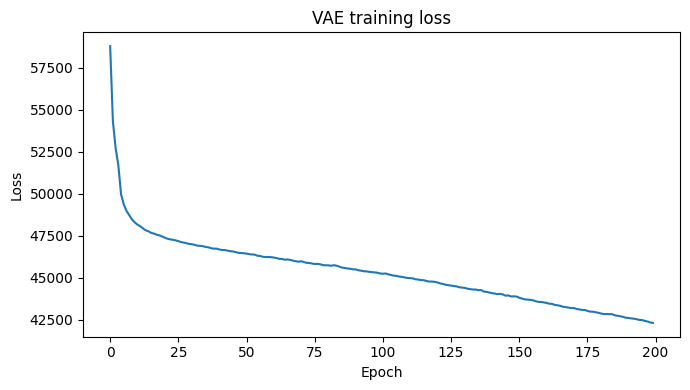

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE training loss")
plt.tight_layout()
plt.show()

In [ ]:
# Extract latent representations
# we pass all 2700 cells through the trained encoder and get back 
# their coordinates in the 10-dimensional latent space.
model.eval()  # switch off dropout/batchnorm if any
## switch the model in evaluation mode.
with torch.no_grad():  # no need to compute gradients, saves memory
    ## we are just passing the data through the netowrk to get the latent
    # representation
    X_gpu = X_tensor.to(device)
    mu, log_var = model.encode(X_gpu)
    ##Runs only the encoder part of the network. Returns two matrices of shape 2700x10, 
    # one for mu and one for log_var. Each row corresponds to a cell, each column to a latent dimension.
    Z = mu.cpu().numpy()  # use mu as the latent representation, not sampled z

print(f"Latent space shape: {Z.shape}")
## this you really did not get, ask tomorrow with fresh brain

Latent space shape: (2700, 10)


In [20]:
# Get cell type annotations
adata_full = sc.datasets.pbmc3k_processed()
cell_types = adata_full.obs['louvain']
print(cell_types.value_counts())

louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


Our adata: 2700 cells
Annotated adata: 2638 cells
Shared: 2638 cells
Z_shared shape: (2638, 10)
Cell types shape: (2638,)


/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


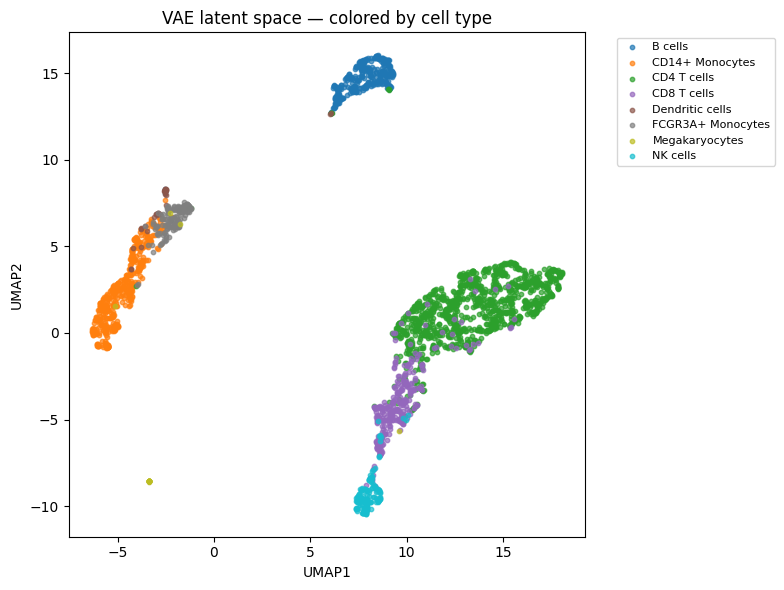

In [ ]:
import umap
import matplotlib.cm as cm

# ── 1. Find shared barcodes ──────────────────────────────────────────
shared_barcodes = adata.obs_names.intersection(adata_full.obs_names)
print(f"Our adata: {adata.n_obs} cells")
print(f"Annotated adata: {adata_full.n_obs} cells")
print(f"Shared: {len(shared_barcodes)} cells")

# ── 2. Filter both to shared barcodes ───────────────────────────────
adata_shared = adata[shared_barcodes]
cell_types_shared = adata_full[shared_barcodes].obs['louvain']

# ── 3. Re-extract latent space for shared cells only ─────────────────
with torch.no_grad():
    X_shared = torch.FloatTensor(adata_shared.X.toarray()).to(device)
    mu_shared, _ = model.encode(X_shared)
    Z_shared = mu_shared.cpu().numpy()

print(f"Z_shared shape: {Z_shared.shape}")
print(f"Cell types shape: {cell_types_shared.shape}")

# ── 4. UMAP on shared latent space ───────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42)
Z_umap = reducer.fit_transform(Z_shared)

# ── 5. Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cell_type_list = cell_types_shared.values
unique_types = sorted(set(cell_type_list))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))

for cell_type, color in zip(unique_types, colors):
    mask = cell_type_list == cell_type
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
               label=cell_type, color=color, alpha=0.7, s=10)

ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("VAE latent space — colored by cell type")
plt.tight_layout()
plt.show()

In [22]:
# Reset model with fresh random weights
model_10 = VAE(input_dim=2000, hidden_dims=[512, 128], latent_dim=10).to(device)
optimizer_10 = torch.optim.Adam(model_10.parameters(), lr=1e-3)

# Train for only 10 epochs
losses_10 = []
for epoch in range(10):
    model_10.train()
    epoch_loss = 0
    for batch in dataloader:
        x = batch[0].to(device)
        x_reconstructed, mu, log_var = model_10(x)
        loss = vae_loss(x_reconstructed, x, mu, log_var)
        optimizer_10.zero_grad()
        loss.backward()
        optimizer_10.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataloader)
    losses_10.append(avg_loss)
    print(f"Epoch {epoch}/10 — Loss: {avg_loss:.1f}")

Epoch 0/10 — Loss: 77814.9
Epoch 1/10 — Loss: 58891.6
Epoch 2/10 — Loss: 56581.3
Epoch 3/10 — Loss: 53384.5
Epoch 4/10 — Loss: 52596.5
Epoch 5/10 — Loss: 51607.6
Epoch 6/10 — Loss: 50573.1
Epoch 7/10 — Loss: 49789.5
Epoch 8/10 — Loss: 49317.5
Epoch 9/10 — Loss: 49051.5


In [26]:
## training loop
from torch.utils.data import DataLoader, TensorDataset

## create dataset adn dataloader
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)

#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

##Training loop
n_epochs = 300
losses = []
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    
    for batch in dataloader:
        x = batch[0].to(device)
        
        #forward pass
        x_reconstructed, mu, log_var = model(x)
        
        ## compute loss
        loss = vae_loss(x_reconstructed, x, mu, log_var)
        
        ##Backward pass
        optimizer.zero_grad()
        # pytorch accumulated gradients by default, you need to zero after each batch
        loss.backward()
        ## computes the gradient of the loss with respect to every 
        # single weight in the network. Pytorch uses the chain rule: 
        # it works backwards through the network from the loss to the 
        # inputs, hence backpropagation."
        optimizer.step()
        ## updates the weights based on the computed gradients. 
        # The Adam optimizer uses an adaptive learning rate for each 
        # parameter, which helps with convergence.
        epoch_loss += loss.item()
        
        
    avg_loss = epoch_loss/len(dataloader)
    losses.append(avg_loss)

    if epoch % 10 ==0:
        print(f"Epoch {epoch}/{n_epochs}, Loss: {avg_loss:.1f}")        

Epoch 0/300, Loss: 42766.1
Epoch 10/300, Loss: 41968.6
Epoch 20/300, Loss: 41735.1
Epoch 30/300, Loss: 41552.3
Epoch 40/300, Loss: 41292.8
Epoch 50/300, Loss: 41109.6
Epoch 60/300, Loss: 40882.1
Epoch 70/300, Loss: 40739.7
Epoch 80/300, Loss: 40534.0
Epoch 90/300, Loss: 40383.2
Epoch 100/300, Loss: 40255.7
Epoch 110/300, Loss: 40093.6
Epoch 120/300, Loss: 39997.3
Epoch 130/300, Loss: 39840.9
Epoch 140/300, Loss: 39671.9
Epoch 150/300, Loss: 39585.4
Epoch 160/300, Loss: 39563.1
Epoch 170/300, Loss: 39421.3
Epoch 180/300, Loss: 39292.5
Epoch 190/300, Loss: 39208.6
Epoch 200/300, Loss: 39132.6
Epoch 210/300, Loss: 39033.5
Epoch 220/300, Loss: 39004.0
Epoch 230/300, Loss: 38897.4
Epoch 240/300, Loss: 38821.3
Epoch 250/300, Loss: 38806.4
Epoch 260/300, Loss: 38730.2
Epoch 270/300, Loss: 38656.1
Epoch 280/300, Loss: 38579.6
Epoch 290/300, Loss: 38574.5


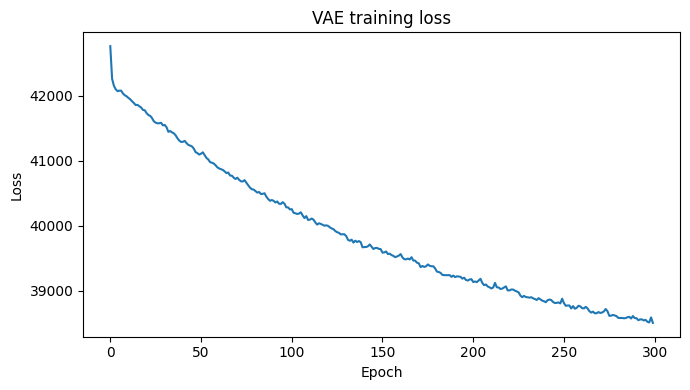

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE training loss")
plt.tight_layout()
plt.show()

Our adata: 2700 cells
Annotated adata: 2638 cells
Shared: 2638 cells
Z_shared shape: (2638, 10)
Cell types shape: (2638,)


/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


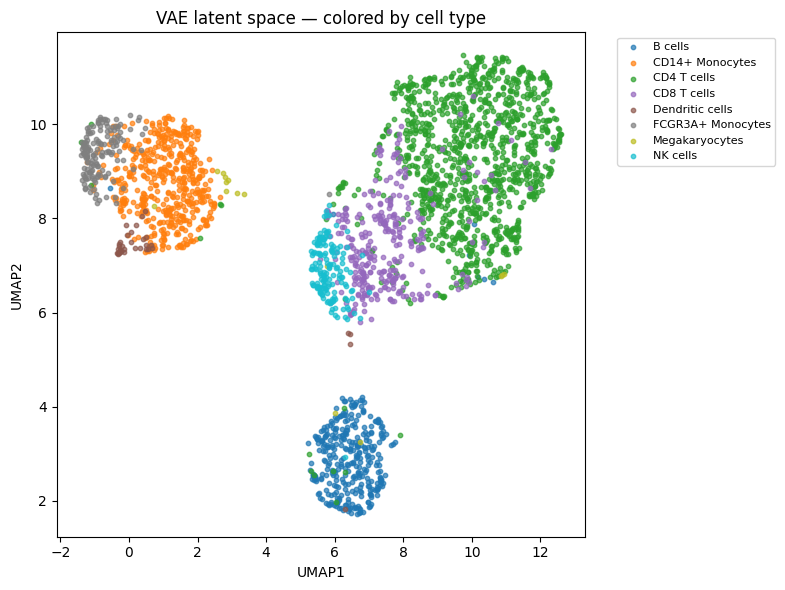

In [28]:
import umap
import matplotlib.cm as cm

# ── 1. Find shared barcodes ──────────────────────────────────────────
shared_barcodes = adata.obs_names.intersection(adata_full.obs_names)
print(f"Our adata: {adata.n_obs} cells")
print(f"Annotated adata: {adata_full.n_obs} cells")
print(f"Shared: {len(shared_barcodes)} cells")

# ── 2. Filter both to shared barcodes ───────────────────────────────
adata_shared = adata[shared_barcodes]
cell_types_shared = adata_full[shared_barcodes].obs['louvain']

# ── 3. Re-extract latent space for shared cells only ─────────────────
with torch.no_grad():
    X_shared = torch.FloatTensor(adata_shared.X.toarray()).to(device)
    mu_shared, _ = model.encode(X_shared)
    Z_shared = mu_shared.cpu().numpy()

print(f"Z_shared shape: {Z_shared.shape}")
print(f"Cell types shape: {cell_types_shared.shape}")

# ── 4. UMAP on shared latent space ───────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42)
Z_umap = reducer.fit_transform(Z_shared)

# ── 5. Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cell_type_list = cell_types_shared.values
unique_types = sorted(set(cell_type_list))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))

for cell_type, color in zip(unique_types, colors):
    mask = cell_type_list == cell_type
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
               label=cell_type, color=color, alpha=0.7, s=10)

ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("VAE latent space — colored by cell type")
plt.tight_layout()
plt.show()

In [29]:
for epoch in range(200):
    model.train()
    epoch_loss = 0
    for batch in dataloader:
        x = batch[0].to(device)
        x_reconstructed, mu, log_var = model(x)
        loss = vae_loss(x_reconstructed, x, mu, log_var)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    if epoch % 50 == 0:
        print(f"Epoch {300+epoch}/500 — Loss: {avg_loss:.1f}")

Epoch 300/500 — Loss: 38487.2
Epoch 350/500 — Loss: 38241.3
Epoch 400/500 — Loss: 38069.0
Epoch 450/500 — Loss: 37853.1


Our adata: 2700 cells
Annotated adata: 2638 cells
Shared: 2638 cells
Z_shared shape: (2638, 10)
Cell types shape: (2638,)


/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


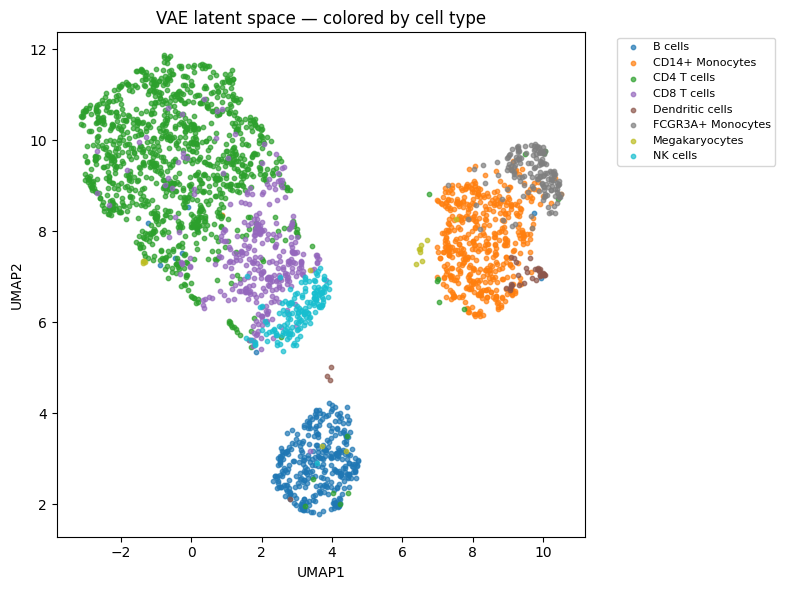

In [30]:
import umap
import matplotlib.cm as cm

# ── 1. Find shared barcodes ──────────────────────────────────────────
shared_barcodes = adata.obs_names.intersection(adata_full.obs_names)
print(f"Our adata: {adata.n_obs} cells")
print(f"Annotated adata: {adata_full.n_obs} cells")
print(f"Shared: {len(shared_barcodes)} cells")

# ── 2. Filter both to shared barcodes ───────────────────────────────
adata_shared = adata[shared_barcodes]
cell_types_shared = adata_full[shared_barcodes].obs['louvain']

# ── 3. Re-extract latent space for shared cells only ─────────────────
with torch.no_grad():
    X_shared = torch.FloatTensor(adata_shared.X.toarray()).to(device)
    mu_shared, _ = model.encode(X_shared)
    Z_shared = mu_shared.cpu().numpy()

print(f"Z_shared shape: {Z_shared.shape}")
print(f"Cell types shape: {cell_types_shared.shape}")

# ── 4. UMAP on shared latent space ───────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42)
Z_umap = reducer.fit_transform(Z_shared)

# ── 5. Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cell_type_list = cell_types_shared.values
unique_types = sorted(set(cell_type_list))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))

for cell_type, color in zip(unique_types, colors):
    mask = cell_type_list == cell_type
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
               label=cell_type, color=color, alpha=0.7, s=10)

ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("VAE latent space — colored by cell type")
plt.tight_layout()
plt.show()

In [ ]:
## the KL space keeps the latent space smooth 
## Reconstruction loss --> encode and decode accurately.
## These two forces are always in tension. The reconstruction loss wants to spread cells out to make them easier to reconstruc tindividually. The KL wants to compress everything into a smooth ball around zer
#The balance bewteen them is what creates the structured latent space you're seeing in th eUMAP

/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


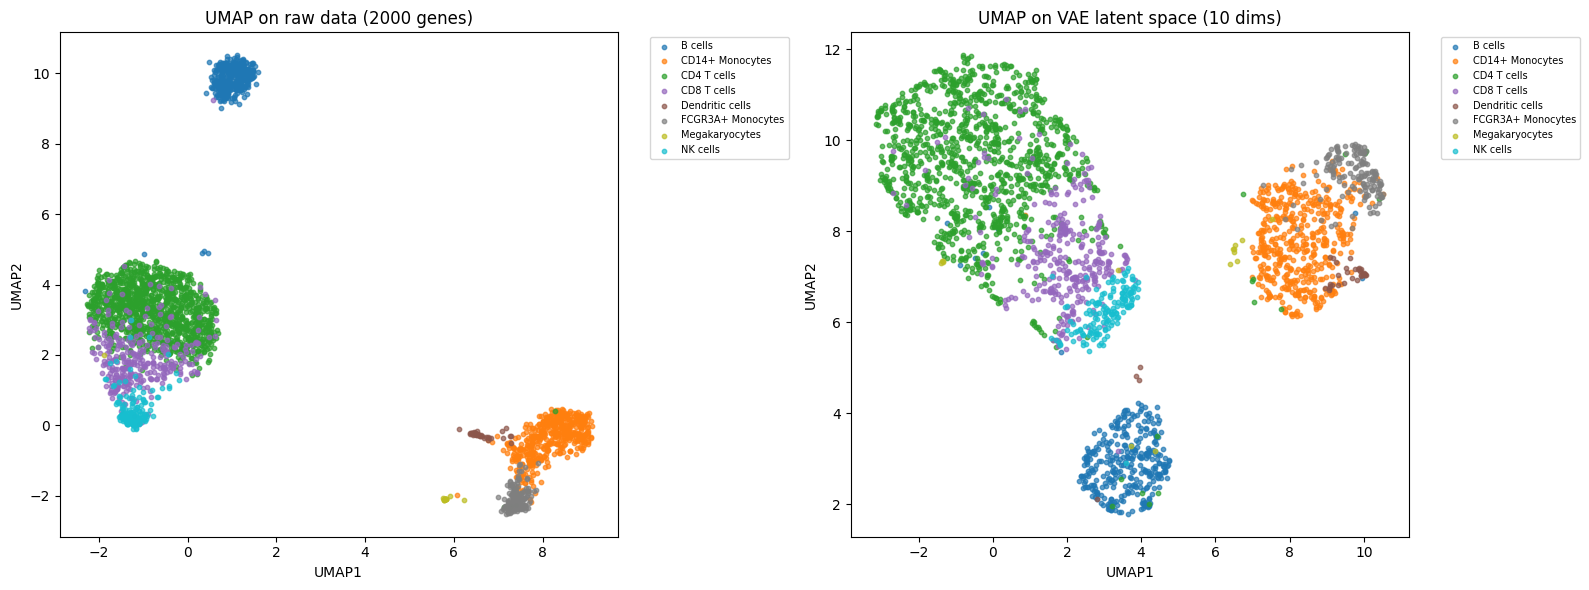

In [32]:
# UMAP directly on raw preprocessed data (no VAE)
reducer_raw = umap.UMAP(n_components=2, random_state=42)
Z_umap_raw = reducer_raw.fit_transform(X_shared.cpu().numpy())

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, Z_plot, title in zip(axes, 
                              [Z_umap_raw, Z_umap],
                              ["UMAP on raw data (2000 genes)", 
                               "UMAP on VAE latent space (10 dims)"]):
    cell_type_list = cell_types_shared.values
    unique_types = sorted(set(cell_type_list))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
    
    for cell_type, color in zip(unique_types, colors):
        mask = cell_type_list == cell_type
        ax.scatter(Z_plot[mask, 0], Z_plot[mask, 1],
                   label=cell_type, color=color, alpha=0.7, s=10)
    
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_title(title)
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()